# ORION Publish Experiments - Norm Control Ablation

## Purpose
Run the **sparse norm-control matrix** to quantify stability/quality/overhead impact.

## What this notebook runs
- Preset: `t4` by default (`PROFILE_PRESET="t4"`)
- Profile: `publish_norm_t4` (or `publish_norm` in full mode)
- Sparse base: `w64_d64`
- Norm variants: `none`, `qk`, `ortho`, `spectral`, and all combinations
- Includes references: `dense`, `window(w64)`
- Sequence lengths:
  - T4 preset: `256, 512, 1024, 2048, 4096`
  - Full preset: `256, 512, 1024, 2048, 4096, 8192`
- Seeds: `123, 456, 789` (3 seeds)
- Planned runs:
  - T4 preset: `150`
  - Full preset: `180`

## Research questions covered
- Which norm controls improve stability without hurting throughput?
- Do combinations beat single controls consistently across lengths?
- What is the recommended default sparse norm configuration?

## Outputs produced
- Run artifacts: `runs/<experiment_id>/...`
- Trial summary: `runs/<experiment_id>/summary.csv`
- Norm-control ranking tables and significance results

## How to execute
1. Run all cells top-to-bottom.
2. Keep configs unchanged to preserve comparability with core/ablation studies.
3. Use produced significance and Pareto outputs for winner selection.

## Handoff
Share final norm ranking (`mean±std`, p-values, Pareto) and selected winner config.


In [3]:
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
USE_GOOGLE_DRIVE = True
REPO_URL = "https://github.com/akashkguw/orion.git"
REPO_REF = os.environ.get("ORION_GIT_REF", "main")  # set to branch/tag/sha if needed

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive/orion")
    REPO_ROOT = DRIVE_ROOT / "repo"
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
else:
    REPO_ROOT = Path("/content/orion") if IN_COLAB else Path.cwd()


def _run(
    cmd: list[str], *, cwd: Path | None = None, check: bool = True
) -> subprocess.CompletedProcess:
    proc = subprocess.run(cmd, cwd=str(cwd) if cwd else None, text=True, capture_output=True)
    if check and proc.returncode != 0:
        raise RuntimeError(
            f"Command failed ({' '.join(cmd)}):\nSTDOUT:\n{proc.stdout}\nSTDERR:\n{proc.stderr}"
        )
    return proc


def _is_git_repo(path: Path) -> bool:
    return (path / ".git").exists()


def _clone_repo(repo_url: str, repo_root: Path, retries: int = 3) -> None:
    last_error = "unknown"
    for attempt in range(1, retries + 1):
        proc = subprocess.run(
            ["git", "clone", repo_url, str(repo_root)],
            text=True,
            capture_output=True,
        )
        if proc.returncode == 0:
            return

        last_error = (proc.stderr or proc.stdout or "clone failed").strip()
        tail = last_error.splitlines()[-1] if last_error else "clone failed"
        print(f"Clone attempt {attempt}/{retries} failed: {tail}")

        if repo_root.exists() and not _is_git_repo(repo_root):
            shutil.rmtree(repo_root, ignore_errors=True)

        if attempt < retries:
            time.sleep(attempt)

    raise RuntimeError(f"Failed to clone repository after {retries} attempts: {last_error}")


def _sync_repo(repo_root: Path, ref: str) -> None:
    # Fail fast on dirty trees so runs stay reproducible.
    status = _run(["git", "status", "--porcelain"], cwd=repo_root)
    if status.stdout.strip():
        raise RuntimeError(
            "Repository has local changes in Drive clone. "
            "Commit/stash/remove them, or delete the repo folder and rerun."
        )

    _run(["git", "fetch", "--all", "--tags", "--prune"], cwd=repo_root)

    # Checkout requested ref; works for local branch, remote branch, tag, or sha.
    checkout = _run(["git", "checkout", ref], cwd=repo_root, check=False)
    if checkout.returncode != 0:
        _run(["git", "checkout", "-B", ref, f"origin/{ref}"], cwd=repo_root)

    # Fast-forward if branch tracks remote.
    branch = _run(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=repo_root).stdout.strip()
    if branch != "HEAD":
        _run(["git", "pull", "--ff-only", "origin", branch], cwd=repo_root)


if REPO_ROOT.exists() and not _is_git_repo(REPO_ROOT):
    if any(REPO_ROOT.iterdir()):
        backup = REPO_ROOT.with_name(f"{REPO_ROOT.name}_backup_{int(time.time())}")
        print(f"Found non-git directory at {REPO_ROOT}; moving to {backup}")
        REPO_ROOT.rename(backup)
    else:
        REPO_ROOT.rmdir()

if not REPO_ROOT.exists():
    REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
    print(f"Cloning {REPO_URL} -> {REPO_ROOT}")
    _clone_repo(REPO_URL, REPO_ROOT)
else:
    print(f"Using existing repository at {REPO_ROOT}")

_sync_repo(REPO_ROOT, REPO_REF)
os.chdir(REPO_ROOT)

commit = _run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT).stdout.strip()
branch = _run(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=REPO_ROOT).stdout.strip()

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_ROOT={REPO_ROOT}")
print(f"Checked out: {branch} @ {commit}")
if IN_COLAB and USE_GOOGLE_DRIVE:
    print(f"Google Drive persistence enabled at: {REPO_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing repository at /content/drive/MyDrive/orion/repo
IN_COLAB=True
REPO_ROOT=/content/drive/MyDrive/orion/repo
Checked out: main @ 99fec83
Google Drive persistence enabled at: /content/drive/MyDrive/orion/repo


In [4]:
print(f"Python: {sys.version}")
if (sys.version_info.major, sys.version_info.minor) != (3, 11):
    print(
        "Warning: Orion is tested primarily on Python 3.11. "
        "Colab may run 3.12; continuing with best-effort installs."
    )


def _pip_install(args: list[str], *, optional: bool = False) -> bool:
    cmd = [sys.executable, "-m", "pip", "install", "-q", *args]
    proc = subprocess.run(cmd, text=True, capture_output=True)
    if proc.returncode == 0:
        return True

    print(f"\n[pip failed] {' '.join(cmd)}")
    if proc.stdout.strip():
        print("--- pip stdout (tail) ---")
        print("\n".join(proc.stdout.splitlines()[-40:]))
    if proc.stderr.strip():
        print("--- pip stderr (tail) ---")
        print("\n".join(proc.stderr.splitlines()[-80:]))

    if optional:
        print("Continuing because this dependency set is optional in notebook runtime.")
        return False

    raise RuntimeError(
        "Required dependency installation failed. "
        "See pip stderr above for the exact package error."
    )


_pip_install(["-U", "pip"])
_pip_install(["-r", "requirements.txt"])
# Dev deps are useful locally/CI, but optional for Colab experiment runs.
_pip_install(["-r", "requirements-dev.txt"], optional=True)
_pip_install(["-e", "."])
_pip_install(["pandas", "seaborn", "matplotlib"])

print("Dependencies installed.")


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Dependencies installed.


In [5]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from orion.experiments import (
    build_trial_specs,
    load_profile_context,
    load_summary_df,
    load_variant_definitions,
    paired_analysis_tables,
    plot_all_numeric_metrics,
    plot_speedup_ratios,
    plot_vram_and_quality,
    prepare_analysis_columns,
    run_profile,
    select_winners,
)

sns.set_theme(style="whitegrid")

PROFILE_PRESET = "t4"  # "t4" | "full"

PROFILE_MAP_BY_PRESET = {
    "t4": {
        "core": "publish_core_t4",
        "ablate_d": "publish_ablate_d_t4",
        "ablate_w": "publish_ablate_w_t4",
        "norm": "publish_norm_t4",
    },
    "full": {
        "core": "publish_core",
        "ablate_d": "publish_ablate_d",
        "ablate_w": "publish_ablate_w",
        "norm": "publish_norm",
    },
}

if PROFILE_PRESET not in PROFILE_MAP_BY_PRESET:
    raise ValueError(f"Unsupported PROFILE_PRESET={PROFILE_PRESET!r}")

PROFILE_MAP = PROFILE_MAP_BY_PRESET[PROFILE_PRESET]

# Toggle sections to control runtime.
RUN_SECTIONS = {
    "core": False,
    "ablate_d": False,
    "ablate_w": False,
    "norm": True,
}

OVERWRITE = False
VAL_PPL_TOLERANCE = 0.20
REQUIRED_SEQ_LENS = (
    [256, 512, 1024, 2048, 4096] if PROFILE_PRESET == "t4" else [256, 512, 1024, 2048, 4096, 8192]
)
MIN_SEEDS_PER_KEY = 3

PROFILE_CTXS = {}
plan_rows = []
for section, profile_name in PROFILE_MAP.items():
    ctx = load_profile_context(profile_name)
    PROFILE_CTXS[section] = ctx
    variants = load_variant_definitions(ctx)
    trial_specs = build_trial_specs(ctx, variants)
    plan_rows.append(
        {
            "section": section,
            "profile": profile_name,
            "selected": RUN_SECTIONS.get(section, False),
            "variants": len(variants),
            "seeds": len(ctx.seeds),
            "seq_lens": ",".join(str(v) for v in ctx.seq_lens),
            "lr_grid": ",".join(str(v) for v in ctx.lr_grid),
            "strict_apples_to_apples": ctx.strict_apples_to_apples,
            "planned_trials": len(trial_specs),
        }
    )

plan_df = pd.DataFrame(plan_rows)
display(plan_df)

,section,profile,selected,variants,seeds,seq_lens,lr_grid,strict_apples_to_apples,planned_trials
0,core,publish_core_t4,False,7,3,"256,512,1024,2048,4096",0.0003,True,105
1,ablate_d,publish_ablate_d_t4,False,8,3,"256,512,1024,2048,4096",0.0003,True,120
2,ablate_w,publish_ablate_w_t4,False,9,3,"256,512,1024,2048,4096",0.0003,True,129
3,norm,publish_norm_t4,True,10,3,"256,512,1024,2048,4096",0.0003,True,150


In [6]:
run_results = {}

for section, enabled in RUN_SECTIONS.items():
    if not enabled:
        print(f"[skip] section={section}")
        continue

    profile_name = PROFILE_MAP[section]
    print(f"\n=== Running section: {section} ({profile_name}) ===")
    result = run_profile(profile_name, overwrite=OVERWRITE)
    run_results[section] = result

if not run_results:
    raise ValueError("No sections selected. Set at least one RUN_SECTIONS[...] = True")

run_manifest = pd.DataFrame(
    [
        {
            "section": section,
            "profile": rr.profile,
            "summary_csv": str(rr.summary_csv),
            "runs_root": str(rr.runs_root),
            "trial_count": rr.trial_count,
        }
        for section, rr in run_results.items()
    ]
)
display(run_manifest)

[skip] section=core
[skip] section=ablate_d
[skip] section=ablate_w

=== Running section: norm (publish_norm_t4) ===
PROFILE: publish_norm_t4
PROFILE_CONFIG_PATH: /content/drive/MyDrive/orion/repo/configs/experiments/profiles/publish_norm_t4.yaml
STRICT_APPLES_TO_APPLES: True
TRAIN_TOKENS_TARGET: 2000000
VARIANTS_IN_PROFILE: 10
RUNS_ROOT: /content/drive/MyDrive/orion/repo/runs/publish_norm_t4_dense_window_sparse_20260312_003649
CFG_ROOT: /content/drive/MyDrive/orion/repo/configs/generated/publish_norm_t4_dense_window_sparse_20260312_003649
PLANNED_TRIALS: 150

[1/150] dense_T256_seed123_lr0p0003
[ok] dense_T256_seed123_lr0p0003 (bs=8, 18.0s)

[2/150] window_w64_T256_seed123_lr0p0003
[ok] window_w64_T256_seed123_lr0p0003 (bs=8, 10.5s)

[3/150] sparse_w64_d64_T256_seed123_lr0p0003
[ok] sparse_w64_d64_T256_seed123_lr0p0003 (bs=8, 26.4s)

[4/150] sparse_w64_d64_qknorm_T256_seed123_lr0p0003
[ok] sparse_w64_d64_qknorm_T256_seed123_lr0p0003 (bs=8, 24.6s)

[5/150] sparse_w64_d64_ortho_T256_see

W0312 00:48:03.215000 811 torch/_dynamo/convert_frame.py:1676] [0/8] torch._dynamo hit config.recompile_limit (8)
W0312 00:48:03.215000 811 torch/_dynamo/convert_frame.py:1676] [0/8]    function: 'flex_attention' (/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1396)
W0312 00:48:03.215000 811 torch/_dynamo/convert_frame.py:1676] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W0312 00:48:03.215000 811 torch/_dynamo/convert_frame.py:1676] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0312 00:48:03.215000 811 torch/_dynamo/convert_frame.py:1676] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html
/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SO


[34/150] sparse_w64_d64_qknorm_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_qknorm_T2048_seed123_lr0p0003 (bs=1, 30.5s)

[35/150] sparse_w64_d64_ortho_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_ortho_T2048_seed123_lr0p0003 (bs=1, 23.7s)

[36/150] sparse_w64_d64_spectral_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_spectral_T2048_seed123_lr0p0003 (bs=1, 25.1s)

[37/150] sparse_w64_d64_qk_ortho_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_qk_ortho_T2048_seed123_lr0p0003 (bs=1, 25.1s)

[38/150] sparse_w64_d64_qk_spectral_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_qk_spectral_T2048_seed123_lr0p0003 (bs=1, 26.6s)

[39/150] sparse_w64_d64_ortho_spectral_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_ortho_spectral_T2048_seed123_lr0p0003 (bs=1, 26.1s)

[40/150] sparse_w64_d64_qk_ortho_spectral_T2048_seed123_lr0p0003
[ok] sparse_w64_d64_qk_ortho_spectral_T2048_seed123_lr0p0003 (bs=1, 27.2s)

[41/150] dense_T4096_seed123_lr0p0003
[ok] dense_T4096_seed123_lr0p0003 (bs=1, 18.0s)

[42/150] window_w64_T4096

,section,profile,summary_csv,runs_root,trial_count
0,norm,publish_norm_t4,/content/drive/MyDrive/orion/repo/runs/publish...,/content/drive/MyDrive/orion/repo/runs/publish...,150


In [7]:
def _safe_float(value):
    try:
        out = float(value)
    except (TypeError, ValueError):
        return np.nan
    return out if math.isfinite(out) else np.nan


def _tail_metrics_from_run_dir(run_dir: str) -> dict[str, float | bool]:
    metrics_path = Path(run_dir) / "metrics.jsonl"
    if not metrics_path.exists():
        return {
            "divergence_rate": np.nan,
            "spike_rate": np.nan,
            "attention_entropy_collapse": np.nan,
            "nan_inf_flag": np.nan,
        }

    last_window = None
    nan_inf_flag = False

    with metrics_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            typ = row.get("type")
            if typ == "window":
                last_window = row
            elif typ == "step":
                if bool(row.get("diverged", False)):
                    nan_inf_flag = True
                for key in ("loss", "ppl", "grad_norm"):
                    value = row.get(key)
                    if value is None:
                        continue
                    try:
                        if not math.isfinite(float(value)):
                            nan_inf_flag = True
                    except (TypeError, ValueError):
                        pass

    out = {
        "divergence_rate": np.nan,
        "spike_rate": np.nan,
        "attention_entropy_collapse": np.nan,
        "nan_inf_flag": float(nan_inf_flag),
    }

    if last_window is not None:
        out.update(
            {
                "divergence_rate": _safe_float(last_window.get("divergence_rate")),
                "spike_rate": _safe_float(last_window.get("spike_rate")),
                "attention_entropy_collapse": float(
                    bool(last_window.get("attention_entropy_collapse", False))
                ),
            }
        )

    return out


frames = []
for section, rr in run_results.items():
    df_i = load_summary_df(rr.summary_csv)
    df_i["section"] = section
    df_i["profile"] = rr.profile
    frames.append(df_i)

df_raw = pd.concat(frames, ignore_index=True)
df = prepare_analysis_columns(df_raw)

enriched = pd.DataFrame([_tail_metrics_from_run_dir(rd) for rd in df["run_dir"].astype(str)])
for col in enriched.columns:
    if col not in df.columns:
        df[col] = enriched[col]
    else:
        df[col] = df[col].where(df[col].notna(), enriched[col])

df_ok = df[df["status"] == "ok"].copy()

print("Successful trials:", len(df_ok), "/", len(df))
display(df_ok.head(20))

Successful trials: 150 / 150


,attention_degree_expected,attn_entropy,attn_entropy_norm,backend,batch_size,cuda_available,cuda_version,duplicate_neighbor_slots,duration_s,error,...,window_mass_pct,section,profile,train_tok_per_s,model_tok_per_s,peak_vram_gb,divergence_rate,spike_rate,attention_entropy_collapse,nan_inf_flag
0,256,4.253881,0.767132,dense,8,True,12.8,NaN,17.977208,NaN,...,NaN,norm,publish_norm_t4,250285.020511,9.208023e+05,0.333984,0.0,0.02,0.0,0.0
1,64,3.256195,0.827100,window,8,True,12.8,NaN,10.508064,NaN,...,NaN,norm,publish_norm_t4,407949.693423,2.109728e+06,0.288086,0.0,0.04,0.0,0.0
2,128,NaN,NaN,sparse,8,True,12.8,0.0,26.367098,NaN,...,NaN,norm,publish_norm_t4,208478.357064,4.524511e+05,0.270508,0.0,0.02,0.0,0.0
3,128,NaN,NaN,sparse,8,True,12.8,0.0,24.645523,NaN,...,NaN,norm,publish_norm_t4,199012.113149,4.490706e+05,0.293945,0.0,0.02,0.0,0.0
4,128,NaN,NaN,sparse,8,True,12.8,0.0,16.138188,NaN,...,NaN,norm,publish_norm_t4,230183.956368,4.445829e+05,0.270508,0.0,0.02,0.0,0.0
5,128,NaN,NaN,sparse,8,True,12.8,0.0,18.379455,NaN,...,NaN,norm,publish_norm_t4,189661.358350,4.325571e+05,0.272461,0.0,0.00,0.0,0.0
6,128,NaN,NaN,sparse,8,True,12.8,0.0,17.438396,NaN,...,NaN,norm,publish_norm_t4,212771.544735,4.420206e+05,0.293945,0.0,0.02,0.0,0.0
7,128,NaN,NaN,sparse,8,True,12.8,0.0,19.666272,NaN,...,NaN,norm,publish_norm_t4,167999.722882,4.086812e+05,0.295898,0.0,0.02,0.0,0.0
8,128,NaN,NaN,sparse,8,True,12.8,0.0,18.432817,NaN,...,NaN,norm,publish_norm_t4,182802.979908,4.138847e+05,0.272461,0.0,0.06,0.0,0.0
9,128,NaN,NaN,sparse,8,True,12.8,0.0,19.309896,NaN,...,NaN,norm,publish_norm_t4,171437.047110,3.965668e+05,0.295898,0.0,0.04,0.0,0.0


In [8]:
def _variant_signature(cfg_path: Path) -> tuple[str, str, str]:
    cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))
    model = cfg.get("model", {})
    optim = dict(cfg.get("optim", {}))
    optim.pop("lr", None)  # lr is swept by profile
    data = cfg.get("data", {})
    dataset = str(data.get("dataset", ""))
    return (
        json.dumps(model, sort_keys=True),
        json.dumps(optim, sort_keys=True),
        dataset,
    )


issues = []

core_ctx = PROFILE_CTXS["core"]
core_variants = load_variant_definitions(core_ctx)
core_backends = {v.backend for v in core_variants}

if sorted(core_ctx.seq_lens) != sorted(REQUIRED_SEQ_LENS):
    issues.append(f"core seq_lens mismatch: expected {REQUIRED_SEQ_LENS}, got {core_ctx.seq_lens}")
if len(core_ctx.seeds) < MIN_SEEDS_PER_KEY:
    issues.append(
        f"core seed count too small: expected >= {MIN_SEEDS_PER_KEY}, got {len(core_ctx.seeds)}"
    )

for backend in ("dense", "window", "sparse"):
    if backend not in core_backends:
        issues.append(f"core missing backend: {backend}")

has_sparse_norm = any(
    (v.backend == "sparse") and any(tok in v.variant_id for tok in ("qk", "ortho", "spectral"))
    for v in core_variants
)
if not has_sparse_norm:
    issues.append("core profile missing sparse+norm variant")

for section, ctx in PROFILE_CTXS.items():
    variants = load_variant_definitions(ctx)
    signatures = {_variant_signature(v.cfg_path) for v in variants}
    if len(signatures) != 1:
        issues.append(
            f"{section} profile is not apples-to-apples on model/optimizer/dataset signatures"
        )

if len(df_ok) > 0:
    success_cov = (
        df_ok.groupby(["section", "backend"])["seq_len"]
        .nunique()
        .reset_index(name="successful_seq_lens")
        .sort_values(["section", "backend"])
    )
    print("Successful seq_len coverage by backend:")
    display(success_cov)

    core_ok = df_ok[df_ok["section"] == "core"].copy()
    if len(core_ok) > 0:
        seed_cov = (
            core_ok.groupby(["backend", "sparse_tag", "seq_len", "lr"])["seed"]
            .nunique()
            .reset_index(name="seed_count")
            .sort_values(["backend", "sparse_tag", "seq_len", "lr"])
        )
        display(seed_cov.head(30))
        under_seeded = seed_cov[seed_cov["seed_count"] < MIN_SEEDS_PER_KEY]
        if len(under_seeded) > 0:
            issues.append(
                f"core run output has under-seeded keys (<{MIN_SEEDS_PER_KEY} seeds): {len(under_seeded)}"
            )

if issues:
    print("Protocol issues found:")
    for item in issues:
        print("-", item)
else:
    print("Protocol checks passed for configured publish-grade criteria.")

Successful seq_len coverage by backend:


,section,backend,successful_seq_lens
0,norm,dense,5
1,norm,sparse,5
2,norm,window,5


Protocol checks passed for configured publish-grade criteria.


In [9]:
TRACK_METRICS = {
    "val_loss": "val_loss",
    "val_ppl": "val_ppl",
    "accuracy_top1": "final_acc_top1",
    "train_tok_per_s": "train_tok_per_s",
    "step_time_ms": "step_time_ms_tail_mean",
    "peak_vram_gb": "peak_vram_gb",
    "valid_neighbors": "valid_neighbors",
    "window_mass_pct": "window_mass_pct",
    "expander_mass_pct": "expander_mass_pct",
    "attn_entropy_norm": "attn_entropy_norm",
    "divergence_rate": "divergence_rate",
    "nan_inf_flag": "nan_inf_flag",
}

for col in TRACK_METRICS.values():
    if col not in df_ok.columns:
        df_ok[col] = np.nan

coverage_rows = []
for backend, g in df_ok.groupby("backend"):
    row = {"backend": backend}
    for label, col in TRACK_METRICS.items():
        row[label] = float(g[col].notna().mean()) if len(g) > 0 else np.nan
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).sort_values("backend")
print(
    "Metric availability fraction by backend (1.0 means always present, 0.0 means unavailable/NA):"
)
display(coverage_df)

Metric availability fraction by backend (1.0 means always present, 0.0 means unavailable/NA):


,backend,val_loss,val_ppl,accuracy_top1,train_tok_per_s,step_time_ms,peak_vram_gb,valid_neighbors,window_mass_pct,expander_mass_pct,attn_entropy_norm,divergence_rate,nan_inf_flag
0,dense,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
1,sparse,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
2,window,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0


In [10]:
pair_keys = ["section", "seq_len", "seed", "lr"]
required_dense_cols = pair_keys + [
    "trial_id",
    "val_ppl",
    "final_acc_top1",
    "train_tok_per_s",
    "peak_vram_gb",
]

for col in required_dense_cols:
    if col not in df_ok.columns:
        df_ok[col] = np.nan

dense = df_ok[df_ok["backend"] == "dense"][required_dense_cols].rename(
    columns={
        "trial_id": "dense_trial_id",
        "val_ppl": "val_ppl_dense",
        "final_acc_top1": "acc_dense",
        "train_tok_per_s": "train_tok_per_s_dense",
        "peak_vram_gb": "peak_vram_gb_dense",
    }
)

non_dense = df_ok[df_ok["backend"] != "dense"].copy()
paired = non_dense.merge(dense, on=pair_keys, how="inner")

paired["val_ppl_delta"] = paired["val_ppl"] - paired["val_ppl_dense"]
paired["acc_delta"] = paired["final_acc_top1"] - paired["acc_dense"]
paired["speed_ratio"] = paired["train_tok_per_s"] / paired["train_tok_per_s_dense"]
paired["vram_ratio"] = paired["peak_vram_gb"] / paired["peak_vram_gb_dense"]

summary = (
    paired.groupby(["section", "backend", "sparse_tag", "seq_len"], as_index=False)
    .agg(
        seeds=("seed", "nunique"),
        val_ppl_delta_mean=("val_ppl_delta", "mean"),
        val_ppl_delta_std=("val_ppl_delta", "std"),
        acc_delta_mean=("acc_delta", "mean"),
        acc_delta_std=("acc_delta", "std"),
        speed_ratio_mean=("speed_ratio", "mean"),
        speed_ratio_std=("speed_ratio", "std"),
        vram_ratio_mean=("vram_ratio", "mean"),
        vram_ratio_std=("vram_ratio", "std"),
    )
    .sort_values(["section", "seq_len", "backend", "sparse_tag"])
)

print("Mean ± std paired summary vs dense:")
display(summary)


def paired_sign_flip_pvalue(values, *, alternative="two-sided", n_perm=20000, seed=2026):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.nan

    obs = float(np.mean(x))
    rng = np.random.default_rng(seed + n)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_perm, n), replace=True)
    null = (signs * x).mean(axis=1)

    if alternative == "greater":
        return (np.sum(null >= obs) + 1.0) / (n_perm + 1.0)
    if alternative == "less":
        return (np.sum(null <= obs) + 1.0) / (n_perm + 1.0)
    return (np.sum(np.abs(null) >= abs(obs)) + 1.0) / (n_perm + 1.0)


sig_rows = []
for keys, g in paired.groupby(["section", "backend", "sparse_tag", "seq_len"], sort=True):
    section, backend, sparse_tag, seq_len = keys

    val_delta = g["val_ppl_delta"].to_numpy(dtype=float)
    acc_delta = g["acc_delta"].to_numpy(dtype=float)
    speed_log = np.log(g["speed_ratio"].replace(0, np.nan).to_numpy(dtype=float))
    vram_log = np.log(g["vram_ratio"].replace(0, np.nan).to_numpy(dtype=float))

    sig_rows.append(
        {
            "section": section,
            "backend": backend,
            "sparse_tag": sparse_tag,
            "seq_len": seq_len,
            "n_pairs": int(g["seed"].nunique()),
            "p_speed_gt_dense": paired_sign_flip_pvalue(speed_log, alternative="greater"),
            "p_vram_lt_dense": paired_sign_flip_pvalue(vram_log, alternative="less"),
            "p_val_ppl_lt_dense": paired_sign_flip_pvalue(val_delta, alternative="less"),
            "p_acc_gt_dense": paired_sign_flip_pvalue(acc_delta, alternative="greater"),
        }
    )

sig_df = pd.DataFrame(sig_rows).sort_values(["section", "seq_len", "backend", "sparse_tag"])
print("Paired sign-flip significance tests (one-sided):")
display(sig_df)

Mean ± std paired summary vs dense:


,section,backend,sparse_tag,seq_len,seeds,val_ppl_delta_mean,val_ppl_delta_std,acc_delta_mean,acc_delta_std,speed_ratio_mean,speed_ratio_std,vram_ratio_mean,vram_ratio_std
0,norm,sparse,w64_d64_none,256,3,-1.166356e-07,1.357625e-07,0.000000,0.000000,0.865954,0.047061,0.809942,0.0
5,norm,sparse,w64_d64_ortho,256,3,-3.924381e-01,5.219865e-02,0.017253,0.011319,0.897133,0.027675,0.809942,0.0
10,norm,sparse,w64_d64_ortho_spectral,256,3,6.286072e-01,2.364781e-01,-0.033854,0.005175,0.710456,0.043030,0.815789,0.0
15,norm,sparse,w64_d64_qk,256,3,-5.456198e-01,6.890204e-02,0.019694,0.010442,0.817636,0.037495,0.880117,0.0
20,norm,sparse,w64_d64_qk_ortho,256,3,-2.362335e-01,1.490026e-01,0.010417,0.007848,0.839015,0.036639,0.880117,0.0
25,norm,sparse,w64_d64_qk_ortho_spectral,256,3,-2.986474e-01,9.032288e-02,0.000977,0.010507,0.670111,0.041334,0.885965,0.0
30,norm,sparse,w64_d64_qk_spectral,256,3,-5.451821e-01,2.312761e-01,0.021159,0.010035,0.661742,0.033822,0.885965,0.0
35,norm,sparse,w64_d64_spectral,256,3,1.036311e+00,8.485089e-02,-0.047689,0.013114,0.729890,0.035388,0.815789,0.0
40,norm,window,w64,256,3,-5.363656e-01,8.621701e-02,0.019857,0.011287,1.475430,0.135286,0.862573,0.0
1,norm,sparse,w64_d64_none,512,3,-1.166791e-07,6.090890e-07,0.000000,0.000000,0.827275,0.024528,0.649203,0.0


Paired sign-flip significance tests (one-sided):


,section,backend,sparse_tag,seq_len,n_pairs,p_speed_gt_dense,p_vram_lt_dense,p_val_ppl_lt_dense,p_acc_gt_dense
0,norm,sparse,w64_d64_none,256,3,1.000000,0.126494,0.246538,1.000000
5,norm,sparse,w64_d64_ortho,256,3,1.000000,0.126494,0.126494,0.126494
10,norm,sparse,w64_d64_ortho_spectral,256,3,1.000000,0.126494,1.000000,1.000000
15,norm,sparse,w64_d64_qk,256,3,1.000000,0.126494,0.126494,0.126494
20,norm,sparse,w64_d64_qk_ortho,256,3,1.000000,0.126494,0.126494,0.126494
25,norm,sparse,w64_d64_qk_ortho_spectral,256,3,1.000000,0.126494,0.126494,0.367232
30,norm,sparse,w64_d64_qk_spectral,256,3,1.000000,0.126494,0.126494,0.126494
35,norm,sparse,w64_d64_spectral,256,3,1.000000,0.126494,1.000000,1.000000
40,norm,window,w64,256,3,0.126494,0.126494,0.126494,0.126494
1,norm,sparse,w64_d64_none,512,3,1.000000,0.126494,0.497775,1.000000


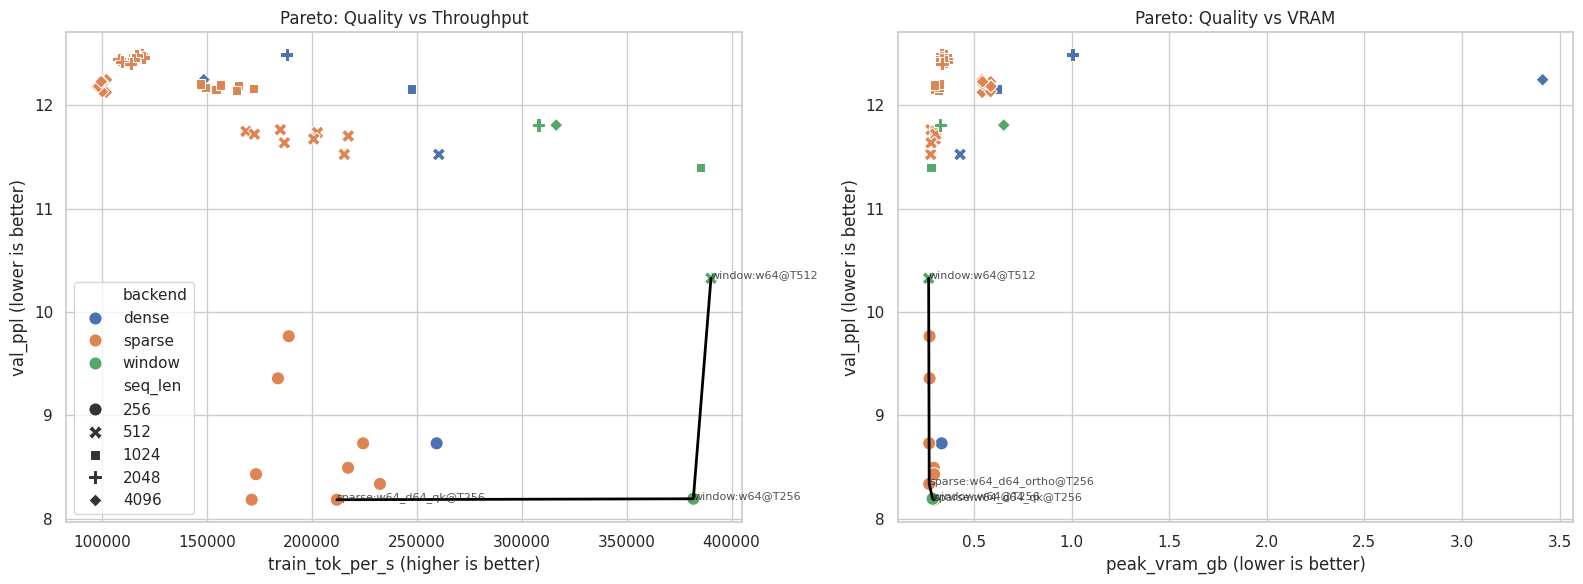

In [11]:
def pareto_mask(x, y, *, maximize_x=True, minimize_y=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)

    keep = np.zeros(len(x), dtype=bool)
    for i in range(len(x)):
        if not finite[i]:
            continue
        dominated = False
        for j in range(len(x)):
            if i == j or not finite[j]:
                continue

            x_better_or_equal = x[j] >= x[i] if maximize_x else x[j] <= x[i]
            y_better_or_equal = y[j] <= y[i] if minimize_y else y[j] >= y[i]

            x_strict = x[j] > x[i] if maximize_x else x[j] < x[i]
            y_strict = y[j] < y[i] if minimize_y else y[j] > y[i]

            if x_better_or_equal and y_better_or_equal and (x_strict or y_strict):
                dominated = True
                break
        keep[i] = not dominated
    return keep


pareto_df = (
    df_ok.groupby(["section", "backend", "sparse_tag", "seq_len"], as_index=False)
    .agg(
        val_ppl=("val_ppl", "mean"),
        train_tok_per_s=("train_tok_per_s", "mean"),
        peak_vram_gb=("peak_vram_gb", "mean"),
        final_acc_top1=("final_acc_top1", "mean"),
    )
    .copy()
)

if "core" in set(pareto_df["section"]):
    pareto_plot_df = pareto_df[pareto_df["section"] == "core"].copy()
else:
    pareto_plot_df = pareto_df.copy()

pareto_plot_df["label"] = (
    pareto_plot_df["backend"]
    + ":"
    + pareto_plot_df["sparse_tag"].astype(str)
    + "@T"
    + pareto_plot_df["seq_len"].astype(str)
)

mask_speed = pareto_mask(
    pareto_plot_df["train_tok_per_s"].to_numpy(),
    pareto_plot_df["val_ppl"].to_numpy(),
    maximize_x=True,
    minimize_y=True,
)
mask_vram = pareto_mask(
    -pareto_plot_df["peak_vram_gb"].to_numpy(),
    pareto_plot_df["val_ppl"].to_numpy(),
    maximize_x=True,
    minimize_y=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pareto_plot_df,
    x="train_tok_per_s",
    y="val_ppl",
    hue="backend",
    style="seq_len",
    s=90,
    ax=axes[0],
)
axes[0].set_title("Pareto: Quality vs Throughput")
axes[0].set_xlabel("train_tok_per_s (higher is better)")
axes[0].set_ylabel("val_ppl (lower is better)")

front_speed = pareto_plot_df[mask_speed].sort_values("train_tok_per_s")
axes[0].plot(front_speed["train_tok_per_s"], front_speed["val_ppl"], color="black", linewidth=2)

sns.scatterplot(
    data=pareto_plot_df,
    x="peak_vram_gb",
    y="val_ppl",
    hue="backend",
    style="seq_len",
    s=90,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Pareto: Quality vs VRAM")
axes[1].set_xlabel("peak_vram_gb (lower is better)")
axes[1].set_ylabel("val_ppl (lower is better)")

front_vram = pareto_plot_df[mask_vram].sort_values("peak_vram_gb")
axes[1].plot(front_vram["peak_vram_gb"], front_vram["val_ppl"], color="black", linewidth=2)

for ax, frontier in [(axes[0], front_speed), (axes[1], front_vram)]:
    for _, row in frontier.iterrows():
        ax.annotate(
            row["label"],
            (row[ax.get_xlabel().split(" ")[0]], row["val_ppl"]),
            fontsize=8,
            alpha=0.8,
        )

plt.tight_layout()
plt.show()

In [12]:
def _extract_w_d(tag: str):
    m = re.search(r"w(\d+)_d(\d+)", str(tag))
    if not m:
        return np.nan, np.nan
    return float(m.group(1)), float(m.group(2))


wd = df_ok["sparse_tag"].map(_extract_w_d)
df_ok["w"] = wd.map(lambda x: x[0])
df_ok["d"] = wd.map(lambda x: x[1])

# Fixed w, sweep d (up to 256)
df_ablate_d = df_ok[(df_ok["section"] == "ablate_d") & (df_ok["backend"] == "sparse")].copy()
if len(df_ablate_d) > 0:
    ablate_d_summary = (
        df_ablate_d.groupby(["seq_len", "d"], as_index=False)
        .agg(
            val_ppl_mean=("val_ppl", "mean"),
            val_ppl_std=("val_ppl", "std"),
            train_tok_s_mean=("train_tok_per_s", "mean"),
            train_tok_s_std=("train_tok_per_s", "std"),
            peak_vram_gb_mean=("peak_vram_gb", "mean"),
            peak_vram_gb_std=("peak_vram_gb", "std"),
        )
        .sort_values(["seq_len", "d"])
    )
    print("Fixed-w sweep-d summary:")
    display(ablate_d_summary)

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=ablate_d_summary, x="d", y="val_ppl_mean", hue="seq_len", marker="o")
    plt.title("Ablation: Fixed w, Sweep d (quality)")
    plt.xlabel("expander degree d")
    plt.ylabel("val_ppl mean")
    plt.show()

# Fixed d, sweep w
df_ablate_w = df_ok[(df_ok["section"] == "ablate_w") & (df_ok["backend"] == "sparse")].copy()
if len(df_ablate_w) > 0:
    ablate_w_summary = (
        df_ablate_w.groupby(["seq_len", "w"], as_index=False)
        .agg(
            val_ppl_mean=("val_ppl", "mean"),
            val_ppl_std=("val_ppl", "std"),
            train_tok_s_mean=("train_tok_per_s", "mean"),
            train_tok_s_std=("train_tok_per_s", "std"),
            peak_vram_gb_mean=("peak_vram_gb", "mean"),
            peak_vram_gb_std=("peak_vram_gb", "std"),
        )
        .sort_values(["seq_len", "w"])
    )
    print("Fixed-d sweep-w summary:")
    display(ablate_w_summary)

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=ablate_w_summary, x="w", y="val_ppl_mean", hue="seq_len", marker="o")
    plt.title("Ablation: Fixed d, Sweep w (quality)")
    plt.xlabel("window size w")
    plt.ylabel("val_ppl mean")
    plt.show()

# Norm-control ablation (none vs qk/ortho/spectral and combos)
for col in ["qk_norm", "ortho_init", "spectral_norm"]:
    if col not in df_ok.columns:
        df_ok[col] = False


def _norm_label(row):
    tags = []
    if bool(row.get("qk_norm", False)):
        tags.append("qk")
    if bool(row.get("ortho_init", False)):
        tags.append("ortho")
    if bool(row.get("spectral_norm", False)):
        tags.append("spectral")
    return "+".join(tags) if tags else "none"


df_norm = df_ok[(df_ok["section"] == "norm") & (df_ok["backend"] == "sparse")].copy()
if len(df_norm) > 0:
    df_norm["norm_label"] = df_norm.apply(_norm_label, axis=1)
    norm_summary = (
        df_norm.groupby("norm_label", as_index=False)
        .agg(
            seeds=("seed", "nunique"),
            val_ppl_mean=("val_ppl", "mean"),
            val_ppl_std=("val_ppl", "std"),
            train_tok_s_mean=("train_tok_per_s", "mean"),
            train_tok_s_std=("train_tok_per_s", "std"),
            peak_vram_gb_mean=("peak_vram_gb", "mean"),
            peak_vram_gb_std=("peak_vram_gb", "std"),
            divergence_rate_mean=("divergence_rate", "mean"),
        )
        .sort_values("val_ppl_mean")
    )
    print("Norm-control ablation summary:")
    display(norm_summary)

Norm-control ablation summary:


,norm_label,seeds,val_ppl_mean,val_ppl_std,train_tok_s_mean,train_tok_s_std,peak_vram_gb_mean,peak_vram_gb_std,divergence_rate_mean
6,qk+spectral,3,11.344252,1.652757,139669.322118,32104.228613,0.372852,0.112938,0.0
1,ortho,3,11.359313,1.586129,168647.483480,53528.060936,0.343945,0.104974,0.0
3,qk,3,11.365550,1.667997,159080.919651,46743.476438,0.370898,0.112938,0.0
4,qk+ortho,3,11.377977,1.515466,159411.003822,47682.148118,0.370898,0.112938,0.0
5,qk+ortho+spectral,3,11.396680,1.554711,139310.615900,32331.271444,0.372852,0.112938,0.0
0,none,3,11.431065,1.440291,166448.018225,51462.113436,0.343945,0.104974,0.0
2,ortho+spectral,3,11.586275,1.183960,147272.842621,36482.087241,0.345898,0.104974,0.0
7,spectral,3,11.646926,1.012226,149059.142347,38225.078668,0.345898,0.104974,0.0


In [13]:
core_df = df_ok[df_ok["section"] == "core"].copy()
if len(core_df) > 0:
    paired_all, paired_focus, agg = paired_analysis_tables(core_df)
    print(f"Paired rows (core, all non-dense variants): {len(paired_all)}")
    print(f"Paired rows (core, focused): {len(paired_focus)}")
    display(agg.sort_values(["seq_len", "backend", "sparse_tag", "lr"]))

    winners = select_winners(agg, val_ppl_tolerance=VAL_PPL_TOLERANCE)
    print("Candidate wins over dense (core):")
    display(winners)

    plot_speedup_ratios(paired_focus)
    plot_vram_and_quality(paired_focus)

plots_root = Path(next(iter(run_results.values())).runs_root).parent
plots_dir = plots_root / "plots_publish_all_metrics"
metric_cols = plot_all_numeric_metrics(df_ok, out_dir=plots_dir, show_inline=False)
print("Saved all-metric plots to:", plots_dir)
print("Numeric metrics plotted:", len(metric_cols))
display(metric_cols)

Discovered numeric metrics: 22
Rendered and saved 22 metric plots to: /content/drive/MyDrive/orion/repo/runs/plots_publish_all_metrics
Saved all-metric plots to: /content/drive/MyDrive/orion/repo/runs/plots_publish_all_metrics
Numeric metrics plotted: 22


['attn_entropy',
 'attn_entropy_norm',
 'duration_s',
 'final_acc_top1',
 'final_loss',
 'final_ppl',
 'grad_norm_tail_mean',
 'model_only_forward_tok_s',
 'model_tok_per_s',
 'ortho_init',
 'peak_vram_gb',
 'qk_norm',
 'spectral_norm',
 'spike_rate',
 'step_time_ms_tail_mean',
 'throughput_tok_s_tail_mean',
 'train_tok_per_s',
 'val_loss',
 'val_ppl',
 'valid_neighbor_fraction_causal_cap',
 'valid_neighbors',
 'vram_peak_mib']